# Práctica 2, Germán Cousillas Martínez

# Apartado 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

xp3 = 0.268
mpi = 0.13957

def sigma(s):
    return np.sqrt(1-4*mpi**2/s)

def t(s, mp3, gamma):
    return xp3*mp3*gamma / sigma(s) / (mp3**2-s-1j*mp3*gamma)

def S(s, mp3, gamma):
    return 1+2j*sigma(s)*t(s, mp3, gamma)

def delta(s, mp3, gamma):
    val = S(s, mp3, gamma)
    return 1/2*np.arctan(val.imag / val.real)*180/np.pi

def n(s, mp3, gamma):
    return np.abs(S(s, mp3, gamma))

raw1 = np.loadtxt("desfasaje_onda_f.dat")

edi = raw1[:,0]
di = raw1[:,1]
Ddi = raw1[:,2]

raw2 = np.loadtxt("elasticidad_onda_f.dat")

enj = raw2[:,0]
nj = raw2[:,1]
Dnj = raw2[:,2]

In [2]:
def razon_aurea(f, x1, x4, tol):
    z = (1+np.sqrt(5))/2
    
    x2 = x4 - (x4-x1)/z
    x3 = x1 + (x4-x1)/z
    
    err = 1.0
    
    while err > tol:
        if f(x2) < f(x3): # Vamos en el buen camino si vamos hacia la izq.
            x4 = x3
            x3 = x2
            x2 = x4 - (x4-x1)/z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4-x1)/z
        err = np.abs(x4-x1)
    return (x1+x4)/2

In [11]:
def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-5)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x, der_y], float)

def max_pendiente(f, X0, tol):

    err = 1.0

    while err > tol:

        v = grad(f, X0) # Dir de mínima pendiente hacia abajo para hallar el mínimo
        # Ahora avanzo un paso en esta dirección
        mod = np.linalg.norm(v)
        
        g = lambda alpha: f(X0[0]+alpha*v[0]/mod, X0[1]+alpha*v[1]/mod)
        
        alpha_opt = razon_aurea(g, -0.5,0.5,10**(-3))
        
        X1 = X0+alpha_opt*v/mod
        #err = np.linalg.norm(X1-X0)
        err = np.abs(alpha_opt)
        X0=X1
    return X1

In [15]:
# Construimos chi2 y la minimizamos para mp3 y gamma

def chi2(mp3, gamma):
    sum1 = np.sum( (di-delta(edi**2,mp3,gamma))**2/Ddi**2 )
    sum2 = np.sum( (nj-n(enj**2,mp3,gamma))**2/Dnj**2 )
    
    return sum1+sum2

# Ahora minimizo chi2



X = max_pendiente(chi2, [1.7, 0.25], 10**(-3))

print(chi2(1.7,0.25))
print(chi2(X[0], X[1]))

186.120563986131
63.66809999605792


In [5]:
import matplotlib.pyplot as plt

# l = np.linspace(-3, 3, 200)

# X, Y = np.meshgrid(l,l)

# Z = np.zeros_like(X)
# c = 0
# for i in range(200):
#     c+=1
#     print(c)
#     for j in range(200):
#         Z[i,j]=chi2(X[i,j], Y[i,j])

plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="hot")
plt.plot(1.7, 0.25, "bo")
plt.colorbar()
plt.show()

NameError: name 'Z' is not defined

# Apartado 2

Procedemos con los datos iniciales habida cuenta de que no me sale bien el cálculo de mp3 y gamma

/tmp/ipykernel_12642/994691559.py:11: RuntimeWarning: divide by zero encountered in divide
  return xp3*mp3*gamma / sigma(s) / (mp3**2-s-1j*mp3*gamma)
/tmp/ipykernel_12642/994691559.py:14: RuntimeWarning: invalid value encountered in multiply
  return 1+2j*sigma(s)*t(s, mp3, gamma)


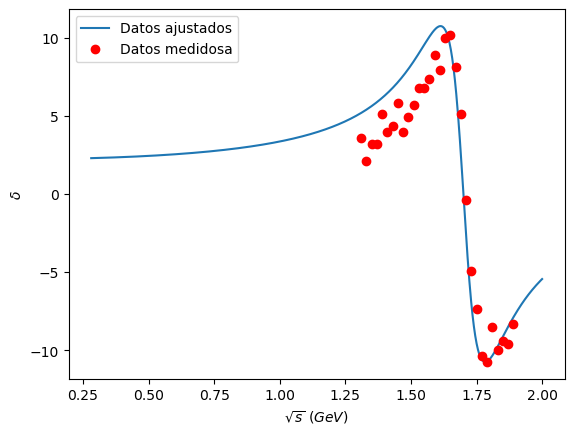

In [38]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(2*mpi, 2, 1000)

# Desfasaje
mp3 = 1.7
gamma = 0.25

plt.figure(1)
plt.plot(x, delta(x**2, mp3, gamma), label="Datos ajustados")
plt.xlabel("$\\sqrt{s} \\ (GeV)$")
plt.ylabel("$\\delta$")

plt.plot(edi, di, "ro", label="Datos medidos")

plt.legend()
plt.show()

/tmp/ipykernel_12642/994691559.py:11: RuntimeWarning: divide by zero encountered in divide
  return xp3*mp3*gamma / sigma(s) / (mp3**2-s-1j*mp3*gamma)
/tmp/ipykernel_12642/994691559.py:14: RuntimeWarning: invalid value encountered in multiply
  return 1+2j*sigma(s)*t(s, mp3, gamma)


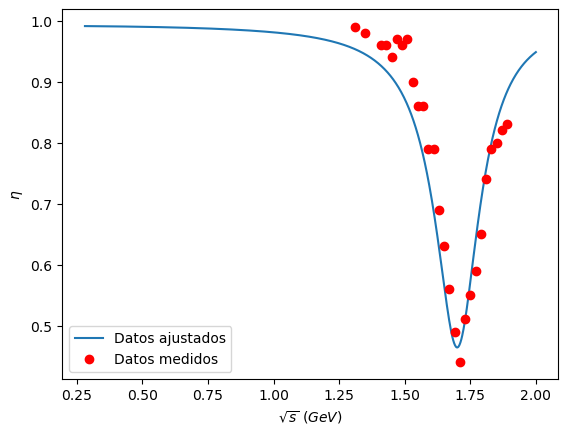

In [39]:
plt.figure(2)
plt.plot(x, n(x**2, mp3, gamma), label="Datos ajustados")
plt.xlabel("$\\sqrt{s} \\ (GeV)$")
plt.ylabel("$\\eta$")

plt.plot(enj, nj, "ro", label="Datos medidos")

plt.legend()
plt.show()

# Apartado 3

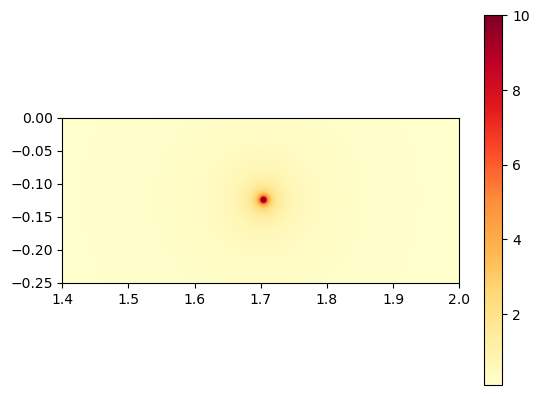

In [53]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1.4, 2, 500)
y = np.linspace(-0.25, 0, 500)

X, Y = np.meshgrid(x, y)

arg = (X+1j*Y)**2
Z = np.abs(t(arg, mp3, gamma))

plt.imshow(Z, origin="lower",cmap="YlOrRd", extent=(1.4, 2, -0.25, 0), vmax=10)
plt.colorbar()
plt.show()

Selecciono punto inicial: $\sqrt{s}=1.7-0.10j$

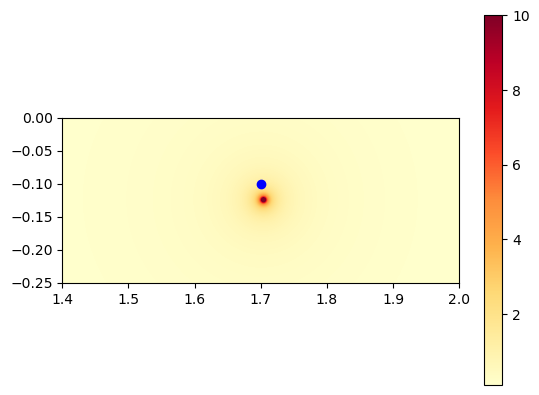

In [55]:
plt.imshow(Z, origin="lower",cmap="YlOrRd", extent=(1.4, 2, -0.25, 0), vmax=10)
plt.plot(1.7, -0.1, "bo")
plt.colorbar()
plt.show()

# Apartado 4

Primero defino las herramientas necesarias para Newton-Raphson, que me sirven para resolver el sistema de ecuaciones que me va a salir al usar este método

In [60]:
# Sust. hacia atrás
import numpy as np

def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x

In [62]:
def make_triang_sup(AB):
    # 1. Ubico elemento máximo y pivoto
    # 2. Divido por pivote toda la fila
    # 3. Resto en cascada multiplicando por la cabeza de cada fila
    
    N = len(AB)
    for i in range(N): # Por cada fila
        col = AB[i:, i] # No puedo tomar como pivote de la fila 2 algo de la fila 1
        pivote = np.max(col)
        ind = np.where(col==pivote)[0][0] + i # No puedo tener en cuenta las filas superiores
        
        # Una vez ubicado el pivote, pivoto fila actual por la de interés
        AB[i,:], AB[ind, :] = AB[ind, :].copy(), AB[i, :].copy()
        
        # Ahora divido por el pivote de la fila
        AB[i,i:] /= pivote
        
        # Finalmente, multiplico por cabeza de cada fila y resto
        for j in range(i+1, N):
            head = AB[j, i]
            AB[j,i:] -= head*AB[i,i:] # Solo resto aquel subconjunto de las filas que es no nulo
        
    return AB

In [63]:
def solveGauss(A, B):
    AB = np.column_stack((A, B))
    triang = make_triang_sup(AB)
    
    A = AB[:,:-1]
    B = AB[:,-1]
    
    return sust_atras(A, B)

In [73]:
# Newton-Raphson en varias variables (sistemas de ecuaciones no lineales)

f = lambda x, y: 1/t((x+1j*y)**2, mp3, gamma)
h = 10**(-5)

import numpy as np

f1 = lambda x, y: f(x, y).real
f2 = lambda x, y: f(x, y).imag

J_1x = lambda x, y: (f1(x+h/2, y)-f1(x-h/2, y))/h
J_1y = lambda x, y: (f1(x, y+h/2)-f1(x, y-h/2))/h
J_2x = lambda x, y: (f2(x+h/2, y)-f2(x-h/2, y))/h
J_2y = lambda x, y: (f2(x, y+h/2)-f2(x, y-h/2))/h

def F(r):
    x, y = r
    return np.array([f1(x, y), f2(x, y)], float)

def J(r):
    x, y = r
    return np.array([[J_1x(x, y), J_1y(x, y)], [J_2x(x, y), J_2y(x, y)]], float)

def newton_raphson_Nvar(X0, tol):
    # Resolvemos el sistema lineal: JD_x = F. No podemos usar LU para actuar sobre J una sola vez porque hay que recalcularlo para cada x1
    err = 1.0
    
    while err > tol:
        J0 = J(X0)
        F0 = F(X0)
        
        Dx = solveGauss(J0, F0)
        X1 = X0-Dx
        
        err = np.max(np.abs(X1-X0))
        X0=X1
        
    return X1

m, gam = newton_raphson_Nvar([1.7, -0.10], 10**(-6))

print(f"Polo: ({m}, {gam})")
print(f"Masa: {m}")
print(f"Gamma: {-gam/2}") # gamma = coord. y / 2 * (-1) según el guión

Polo: (1.7045648780795537, -0.1246652460887337)
Masa: 1.7045648780795537
Gamma: 0.06233262304436685
